# GW170817 PE — Fixed sky location (NGC 4993), 128 s segments

Parameter estimation of GW170817 with **sky location fixed** to the known EM counterpart (NGC 4993):
$$\alpha = 3.44616\;\mathrm{rad}, \quad \delta = -0.408084\;\mathrm{rad}$$

Based on the full-sky run, RA and Dec converged correctly to literature values, so we fix them here to focus sampling effort on the remaining 11 parameters.

- **Waveform**: `mlgw_bns_jax` (JAX-based BNS approximant), injected into SHARPy via **monkey-patching**
- **Sampler**: SHARPy SMC (Sequential Monte Carlo)
- **Data**: 1024 s of GWOSC strain for H1, L1, V1 — L1 glitch subtracted via **BayesWave** ([DCC LIGO-T1700406-v3](https://dcc.ligo.org/LIGO-T1700406/public))
- **Segment duration**: 128 s (matching the paper, $\Delta f \approx 0.0078$ Hz)
- **Frequency range**: $[23, 2000]$ Hz

**Google Colab**: Open this notebook directly from GitHub via `File → Open notebook → GitHub` and paste the repository URL. For **private repos**, use a GitHub personal access token in the Colab GitHub dialog.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/saulo-albuquerque-phys/mlgw_bns_jax/blob/jax_mlgw_bns/sharpy_mlgw_bns_jax_pe_fixedsky.ipynb)

**11 sampled parameters** (RA and Dec fixed):

| Index | Parameter | Prior range | Boundary |
|:---:|---|---|---|
| 0 | $\ln d_L$ | $[\ln 1, \ln 75]$ | reflective |
| 1 | $\theta_{JN}$ (inclination) | $[0, \pi]$ | reflective |
| 2 | $\phi_c$ (phase) | $[0, 2\pi]$ | periodic |
| 3 | $\psi$ (polarisation) | $[0, \pi]$ | periodic |
| 4 | $\mathcal{M}_c$ (chirp mass) | $[1.18, 1.21]\,M_\odot$ | reflective |
| 5 | $q$ (mass ratio) | $[0.5, 1.0]$ | reflective |
| 6 | $t_c$ (coalescence time) | $[-0.1, 0.1]\,\mathrm{s}$ | reflective |
| 7 | $\chi_1$ (spin 1) | $[-0.5, 0.5]$ | reflective |
| 8 | $\chi_2$ (spin 2) | $[-0.5, 0.5]$ | reflective |
| 9 | $\Lambda_1$ (tidal 1) | $[5, 5000]$ | reflective |
| 10 | $\Lambda_2$ (tidal 2) | $[5, 5000]$ | reflective |

## Environment setup (Colab / fresh environment)

This cell installs all required packages and clones the repositories. **Skip if running locally** with everything already installed.

In [1]:
import os, subprocess, sys

COLAB = "google.colab" in sys.modules
REPO_DIR = "/content/mlgw_bns_jax" if COLAB else os.getcwd()

if COLAB:
    # ── Install JAX with CUDA 12 support ─────────────────────────────
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "jax[cuda12]",
        "-f", "https://storage.googleapis.com/jax-releases/jax_cuda_releases.html",
    ])
    # ── Install other Python packages ────────────────────────────────
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "corner", "gwpy", "h5py", "ripplegw",
    ])

    # ── Clone the main repo (contains model, waveform loader, etc.) ──
    if not os.path.isdir(REPO_DIR):
        subprocess.check_call([
            "git", "clone", "--branch", "jax_mlgw_bns", "--depth", "1",
            "https://github.com/saulo-albuquerque-phys/mlgw_bns_jax.git",
            REPO_DIR,
        ])

    # ── Clone SHARPy (no __init__.py → add to sys.path, not pip) ─────
    # Clone into REPO_DIR/sharpy so that `import sharpy.GW_likelihood` works
    # when REPO_DIR is the cwd or on sys.path.
    sharpy_repo = os.path.join(REPO_DIR, "_sharpy_repo")
    sharpy_pkg  = os.path.join(sharpy_repo, "sharpy")
    sharpy_link = os.path.join(REPO_DIR, "sharpy")
    if not os.path.isdir(sharpy_repo):
        subprocess.check_call([
            "git", "clone", "--depth", "1",
            "https://github.com/saulo-albuquerque-phys/sharpy.git",
            sharpy_repo,
        ])
    # Symlink so `import sharpy` finds the package inside the cloned repo
    if not os.path.exists(sharpy_link):
        os.symlink(sharpy_pkg, sharpy_link)

    os.chdir(REPO_DIR)
    print(f"Working directory: {os.getcwd()}")
    print(f"SHARPy: {sharpy_link} -> {sharpy_pkg}")
else:
    print("Not running on Colab — skipping setup.")

Not running on Colab — skipping setup.


## Download GWOSC data (BayesWave-cleaned L1)

Downloads 1024 s of 4 kHz strain from GWOSC for H1, L1 and V1.

For **L1**, the scatter-light glitch near the merger is removed using the
official **BayesWave glitch subtraction** from
[DCC LIGO-T1700406-v3](https://dcc.ligo.org/LIGO-T1700406/public) —
the same cleaned data used for the GWTC-1 parameter estimation
(Abbott+ 2019, PRX 9, 011001).

The cleaned GWF covers GPS ≥ 1187008667 (553 s into our 1024 s window).
We splice: raw L1 for the earlier portion + BayesWave-cleaned for
the rest.

**Skip if the cleaned files already exist.**

In [2]:
import os, sys, time, shutil
import numpy as np

_GPS_START = 1187008114
_DURATION  = 1024
_SRATE     = 4096
_DATA_DIR  = "gw170817_data"
os.makedirs(_DATA_DIR, exist_ok=True)

_DETECTORS = ["H1", "L1", "V1"]

# ── BayesWave-subtracted L1 data from DCC LIGO-T1700406-v3 ──────────
_DCC_GWF_URL = (
    "https://dcc.ligo.org/public/0144/T1700406/003/"
    "L-L1_CLEANED_HOFT_C02_T1700406_v3-1187008667-4096.gwf"
)
_DCC_CHANNEL = "L1:DCH-CLEAN_STRAIN_C02_T1700406_v3"
_DCC_GPS0    = 1187008667
_DCC_SRATE   = 16384


def _ensure_gwf_backend():
    """Make sure at least one GWF reader is importable."""
    for mod in ("frameCPP", "lalframe", "framel"):
        try:
            __import__(mod)
            return
        except ImportError:
            pass
    conda = shutil.which("conda") or shutil.which("mamba")
    if conda:
        import subprocess
        for pkg in ("framel", "python-lalframe"):
            print(f"  Trying: {conda} install -c conda-forge {pkg}", flush=True)
            ret = subprocess.call([conda, "install", "-c", "conda-forge", "-y", "-q", pkg])
            if ret == 0:
                return
    import subprocess
    for pkg in ("framel",):
        ret = subprocess.call([sys.executable, "-m", "pip", "install", "-q", pkg])
        if ret == 0:
            return
    raise ImportError(
        "Cannot read GWF files. Install a backend manually:\n"
        "  conda install -c conda-forge framel\n"
    )


def _read_gwf_channel(path, channel, start, end):
    """Read a single channel from a GWF file (try gwpy then framel)."""
    try:
        from gwpy.timeseries import TimeSeries
        ts = TimeSeries.read(path, channel, start=start, end=end)
        return np.asarray(ts.value, dtype=np.float64), float(ts.sample_rate.value)
    except Exception:
        pass
    import framel
    vec = framel.frgetvect1d(path, channel, start, end - start, 0)
    data = np.asarray(vec[0], dtype=np.float64)
    sr   = 1.0 / vec[3]
    return data, sr


_all_exist = all(
    os.path.isfile(os.path.join(_DATA_DIR,
        f"{d[0]}-{d}_BWCLEANED_4KHZ-{_GPS_START}-{_DURATION}.txt"))
    for d in _DETECTORS
)

if _all_exist:
    print("Cleaned data files already exist — skipping download.")
else:
    from gwpy.timeseries import TimeSeries
    from scipy.signal import decimate as _decimate

    for det in _DETECTORS:
        out_file = os.path.join(_DATA_DIR,
            f"{det[0]}-{det}_BWCLEANED_4KHZ-{_GPS_START}-{_DURATION}.txt")

        if det == "L1":
            print("L1: building cleaned timeseries")
            t0 = time.time()

            print("  Downloading raw L1 from GWOSC...", flush=True)
            ts_raw = TimeSeries.fetch_open_data(
                "L1", _GPS_START, _GPS_START + _DURATION, sample_rate=_SRATE)

            gwf_local = os.path.join(_DATA_DIR, "L1_cleaned_bw_T1700406.gwf")
            if not os.path.isfile(gwf_local):
                import requests
                print("  Downloading BayesWave GWF from DCC (~1 GB)…", flush=True)
                resp = requests.get(_DCC_GWF_URL, stream=True)
                resp.raise_for_status()
                with open(gwf_local, "wb") as fout:
                    for chunk in resp.iter_content(chunk_size=1 << 20):
                        fout.write(chunk)
                print(f"  Saved GWF ({os.path.getsize(gwf_local)/1e6:.0f} MB)")
            else:
                print("  BayesWave GWF already cached.")

            _ensure_gwf_backend()

            _need_end = _GPS_START + _DURATION
            print("  Reading cleaned segment from GWF...", flush=True)
            bw_data, bw_sr = _read_gwf_channel(
                gwf_local, _DCC_CHANNEL, _DCC_GPS0, _need_end)

            if int(round(bw_sr)) != _SRATE:
                factor = int(round(bw_sr)) // _SRATE
                print(f"  Resampling {int(bw_sr)} -> {_SRATE} Hz (factor {factor})")
                bw_data = _decimate(bw_data, factor, ftype="iir", zero_phase=True)

            n_raw = int((_DCC_GPS0 - _GPS_START) * _SRATE)
            strain = np.concatenate([ts_raw.value[:n_raw], bw_data])
            n_expected = _DURATION * _SRATE
            assert len(strain) == n_expected, (
                f"L1 splice length mismatch: {len(strain)} vs {n_expected}")

            with open(out_file, "w") as fw:
                fw.write("# BayesWave-cleaned L1 strain for GW170817\n")
                fw.write(f"# GPS [{_GPS_START}, {_GPS_START+_DURATION}], "
                         f"splice at GPS {_DCC_GPS0}\n")
                fw.write("# Before splice: raw GWOSC.  After: DCC T1700406-v3 (BayesWave)\n")
                fw.write(f"# {_SRATE} samples per second\n")
                for val in strain:
                    fw.write(f"{val:.16e}\n")
            print(f"  -> L1 done in {time.time()-t0:.1f}s")

        else:
            print(f"{det}: downloading {_DURATION}s from GWOSC…", flush=True)
            t0 = time.time()
            ts = TimeSeries.fetch_open_data(
                det, _GPS_START, _GPS_START + _DURATION, sample_rate=_SRATE)
            with open(out_file, "w") as fw:
                fw.write(f"# {det}: raw GWOSC strain for GW170817\n")
                fw.write(f"# {_SRATE} samples per second\n")
                fw.write(f"# starting GPS {_GPS_START} duration {_DURATION}\n")
                for val in ts.value:
                    fw.write(f"{val:.16e}\n")
            print(f"  -> saved in {time.time()-t0:.1f}s")

    print("All detectors ready.")

Cleaned data files already exist — skipping download.


In [3]:
from __future__ import annotations

import os, sys, time
from functools import partial

import numpy as np

# Use GPU if available on Colab, otherwise CPU
if "google.colab" not in sys.modules:
    os.environ.setdefault("JAX_PLATFORMS", "cpu")

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


## Load the waveform model and monkey-patch SHARPy

We replace the original `IMRPhenomD` template in SHARPy with our `mlgw_bns_jax` BNS waveform model **without modifying any SHARPy source file**.

In [4]:
from jax_import_n_predict import load_predict

MODEL_PATH = "mlgw_bns_jax_model.h5"
_mlgw_predict = load_predict(MODEL_PATH)

# ---- Monkey-patch SHARPy's template -----------------------------------
import sharpy.GW_likelihood as _gw_mod
from sharpy.utils import McQ2Masses


def _template_mlgw_bns(params, frequency_array):
    """mlgw_bns_jax waveform, drop-in replacement for SHARPy's template."""
    mc, q = params[6], params[7]
    m1, m2 = McQ2Masses(mc, q)
    total_mass = m1 + m2
    chi1, chi2 = params[9], params[10]
    lambda_1, lambda_2 = params[11], params[12]
    phic = params[4]
    dist_mpc = jnp.exp(params[2])
    inclination = params[3]

    mlgw_params = jnp.array([q, lambda_1, lambda_2, chi1, chi2])
    hp, hc = _mlgw_predict(
        mlgw_params, frequency_array,
        total_mass=total_mass,
        distance_mpc=dist_mpc,
        inclination=inclination,
    )
    phase_factor = jnp.exp(-1j * phic)
    return hp * phase_factor, hc * phase_factor


_gw_mod.template = _template_mlgw_bns

from sharpy.GW_likelihood import GWNetwork, log_likelihood_det
from sharpy.smc_functions import run_sharpy
import sharpy.PSDs

print("Model loaded — SHARPy template patched with mlgw_bns_jax.")

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: If timeit=True signals high \% spent sampling n_discarded, consider lowering it.

Model loaded — SHARPy template patched with mlgw_bns_jax.


## Event parameters

In [5]:
TRIGGER_TIME = 1187008882.43
SEGMENT_DURATION = 128.0        # paper-matching segment length
SAMPLING_RATE = 4096
F_LOWER = 23.0
F_UPPER = 2000.0
DATA_START_GPS = 1187008114     # 1024s data file start
DATA_DURATION = 1024            # total data length (s)

# Fixed sky location: NGC 4993 (EM counterpart of GW170817)
FIXED_RA  = 3.44616     # rad
FIXED_DEC = -0.408084   # rad

DATA_DIR = "gw170817_data"
OUTDIR = "outdir_GW170817_sharpy_fixedsky"
LABEL = "GW170817_sharpy_fixedsky"
os.makedirs(OUTDIR, exist_ok=True)

print(f"Segment duration: {SEGMENT_DURATION}s  →  Δf = {1/SEGMENT_DURATION:.4f} Hz")
print(f"Data: {DATA_DURATION}s starting GPS {DATA_START_GPS}")
print(f"Fixed sky: RA = {FIXED_RA:.5f} rad, Dec = {FIXED_DEC:.6f} rad  (NGC 4993)")

Segment duration: 128.0s  →  Δf = 0.0078 Hz
Data: 1024s starting GPS 1187008114
Fixed sky: RA = 3.44616 rad, Dec = -0.408084 rad  (NGC 4993)


## Load cleaned data and build detector network

We use 1024 s of GWOSC strain data. For L1, the scatter-light glitch near the merger is removed using the official **BayesWave glitch subtraction** from [DCC LIGO-T1700406-v3](https://dcc.ligo.org/LIGO-T1700406/public). H1 and V1 use raw GWOSC data (no significant glitches).

With `SEGMENT_DURATION = 128 s`, SHARPy analyses a 128-s chunk centred on the trigger and uses the remaining ~896 s for Welch PSD estimation (~7 independent segments).

In [6]:
# BayesWave-cleaned 1024s files (L1 BW-cleaned, H1/V1 raw GWOSC)
data_files = {
    "H1": os.path.join(DATA_DIR, f"H-H1_BWCLEANED_4KHZ-{DATA_START_GPS}-{DATA_DURATION}.txt"),
    "L1": os.path.join(DATA_DIR, f"L-L1_BWCLEANED_4KHZ-{DATA_START_GPS}-{DATA_DURATION}.txt"),
    "V1": os.path.join(DATA_DIR, f"V-V1_BWCLEANED_4KHZ-{DATA_START_GPS}-{DATA_DURATION}.txt"),
}
for det, f in data_files.items():
    assert os.path.isfile(f), f"Missing: {f}"
    print(f"{det}: {os.path.basename(f)}")

detector_settings = {}
for det in ["H1", "L1", "V1"]:
    detector_settings[det] = dict(
        data_file=data_files[det], channel="GWOSC",
        trigger_time=TRIGGER_TIME, duration=SEGMENT_DURATION,
        sampling_rate=SAMPLING_RATE,
        f_lower=F_LOWER, f_upper=F_UPPER,
        psd_file=None, psd_method="welch",
        download_data=False, zero_noise=False,
    )

print(f"\nBuilding GW network (segment={SEGMENT_DURATION}s)...")
t0 = time.time()
gw_network = GWNetwork(detector_settings, injection_parameters=None)
print(f"Network built in {time.time() - t0:.2f} s")

/workspaces/mlgw_bns_jax/sharpy/noise.py:242: UserWarning: The file name is expected to follow LIGO-Virgo conventions 'DET-FRAMETYPE-STARTTIME--DATALEN.txt', e.g.: 'H-H1_GWOSC_4_V1-1126259446-32.txt'. See https://www.gw-openscience.org for more infomation.
  warnings.warn("The file name is expected to follow LIGO-Virgo conventions 'DET-FRAMETYPE-STARTTIME--DATALEN.txt', e.g.: 'H-H1_GWOSC_4_V1-1126259446-32.txt'. See https://www.gw-openscience.org for more infomation.")


H1: H-H1_BWCLEANED_4KHZ-1187008114-1024.txt
L1: L-L1_BWCLEANED_4KHZ-1187008114-1024.txt
V1: V-V1_BWCLEANED_4KHZ-1187008114-1024.txt

Building GW network (segment=128.0s)...
Loading gw170817_data/H-H1_BWCLEANED_4KHZ-1187008114-1024.txt starting at 1187008114.0 length 1024.0s


Estimating power spectral density with the Welch method
Loading gw170817_data/L-L1_BWCLEANED_4KHZ-1187008114-1024.txt starting at 1187008114.0 length 1024.0s
Estimating power spectral density with the Welch method
Loading gw170817_data/V-V1_BWCLEANED_4KHZ-1187008114-1024.txt starting at 1187008114.0 length 1024.0s
Estimating power spectral density with the Welch method
Network built in 7.44 s


## Q-transform spectrograms

Verify the data quality: compare raw vs BayesWave-cleaned L1, and show all three cleaned detectors around the merger time.

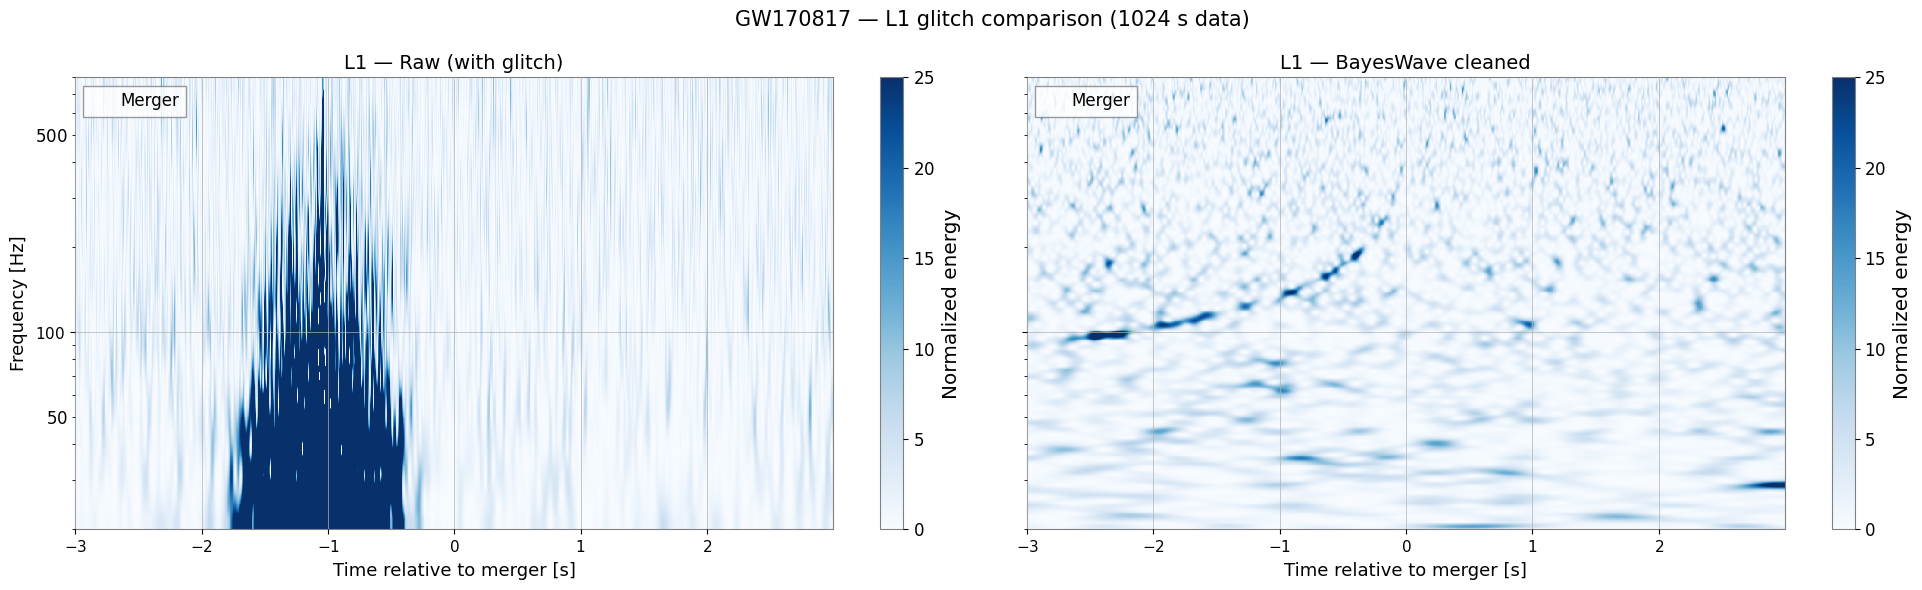

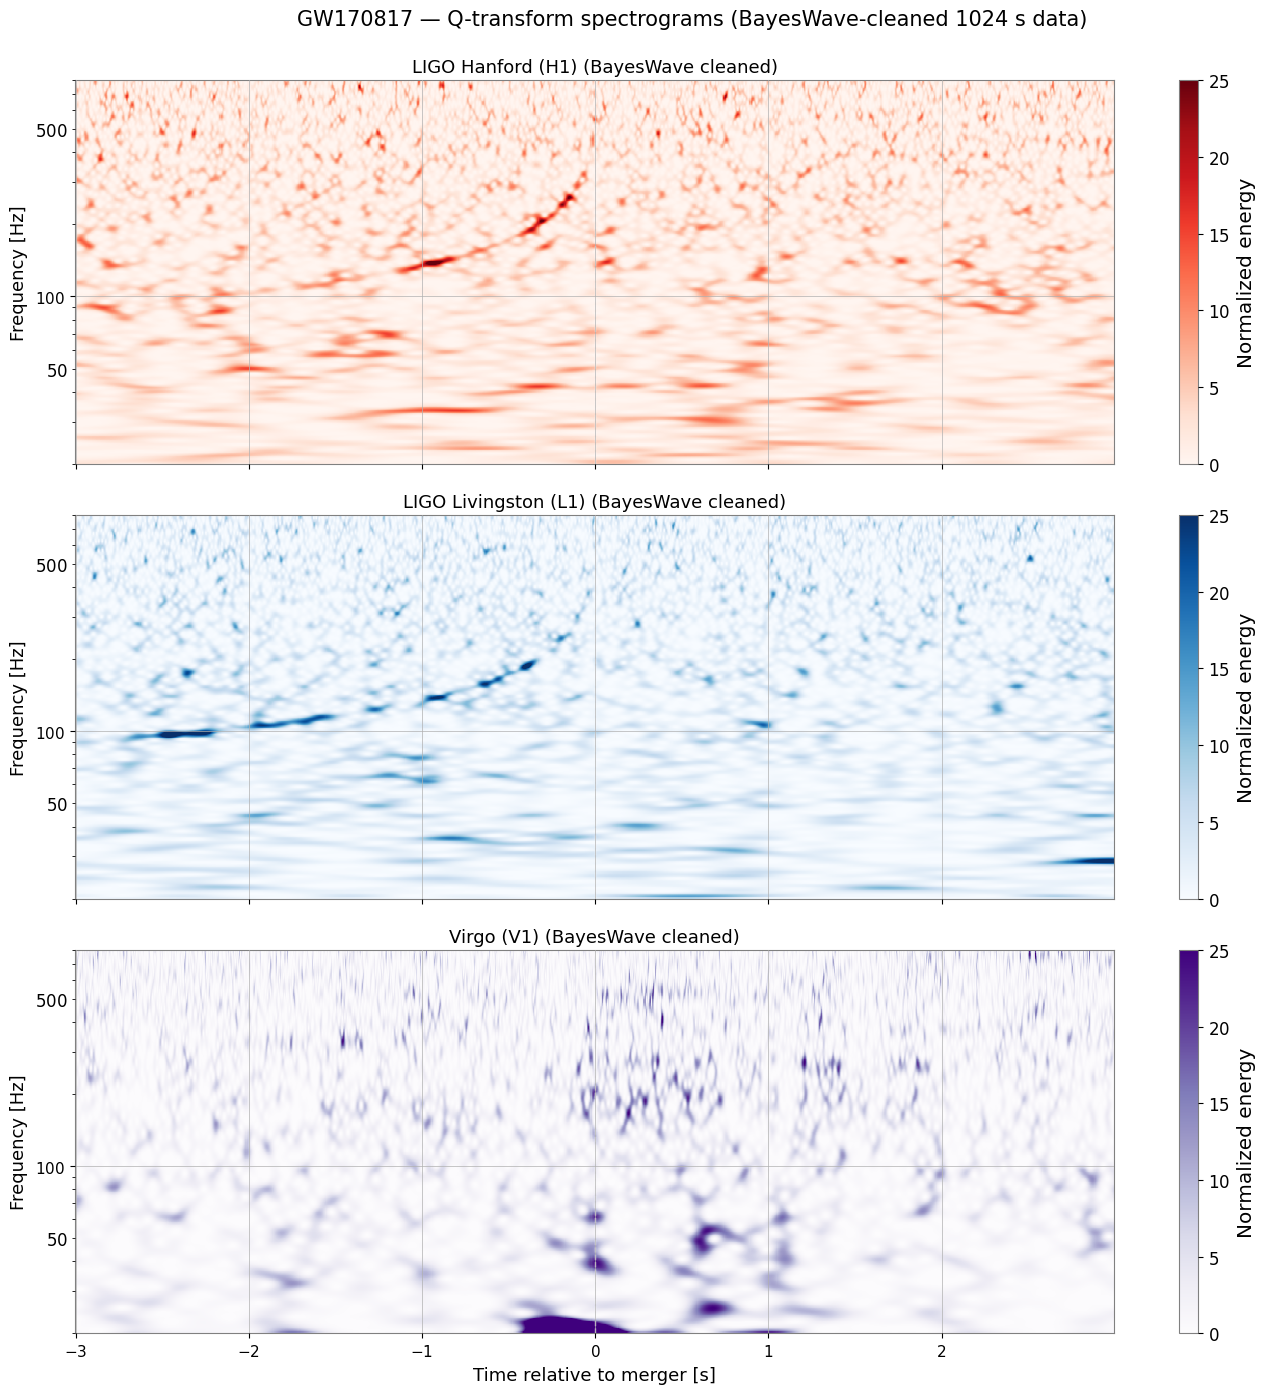

Spectrograms saved.


In [7]:
from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

MERGER_GPS = TRIGGER_TIME
WINDOW = 6.0
T_START_PLOT = MERGER_GPS - WINDOW / 2
T_END_PLOT   = MERGER_GPS + WINDOW / 2
F_MIN, F_MAX = 20.0, 800.0
Q_RANGE = (4, 64)

DET_COLORS = {"H1": "Reds", "L1": "Blues", "V1": "Purples"}
DET_LABELS = {"H1": "LIGO Hanford (H1)", "L1": "LIGO Livingston (L1)", "V1": "Virgo (V1)"}

def _qtransform(filepath):
    strain = np.loadtxt(filepath, comments="#")
    ts = TimeSeries(strain, sample_rate=SAMPLING_RATE, t0=DATA_START_GPS)
    ts_w = ts.whiten(4, 2)
    ts_c = ts_w.crop(T_START_PLOT - 1, T_END_PLOT + 1)
    return ts_c.q_transform(frange=(F_MIN, F_MAX), qrange=Q_RANGE,
                            outseg=(T_START_PLOT, T_END_PLOT), logf=True)

# ── L1 raw vs cleaned comparison ─────────────────────────────────────
raw_file = os.path.join(DATA_DIR,
    f"L-L1_GWOSC_4KHZ_R1-{DATA_START_GPS}-{DATA_DURATION}.txt")

if os.path.isfile(raw_file):
    qt_raw = _qtransform(raw_file)
    qt_cln = _qtransform(data_files["L1"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
    for ax, qt, title in [(ax1, qt_raw, "L1 — Raw (with glitch)"),
                           (ax2, qt_cln, "L1 — BayesWave cleaned")]:
        pcm = ax.pcolormesh(qt.times.value - MERGER_GPS, qt.frequencies.value,
                            qt.value.T, cmap="Blues", vmin=0, vmax=25)
        ax.set_yscale("log"); ax.set_ylim(F_MIN, F_MAX)
        ax.set_xlabel("Time relative to merger [s]", fontsize=13)
        ax.set_title(title, fontsize=14)
        ax.axvline(0, color="white", ls="--", lw=1, alpha=0.7, label="Merger")
        ax.legend(loc="upper left"); ax.tick_params(labelsize=11)
        fig.colorbar(pcm, ax=ax).set_label("Normalized energy")
    ax1.set_ylabel("Frequency [Hz]", fontsize=13)
    fig.suptitle("GW170817 — L1 glitch comparison (1024 s data)", fontsize=15)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, f"{LABEL}_L1_comparison.png"), dpi=150)
    plt.show()
else:
    print(f"Raw L1 file not found ({raw_file}) — skipping glitch comparison.")

# ── All detectors cleaned ────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
for ax, det in zip(axes, ["H1", "L1", "V1"]):
    qt = _qtransform(data_files[det])
    pcm = ax.pcolormesh(qt.times.value - MERGER_GPS, qt.frequencies.value,
                        qt.value.T, cmap=DET_COLORS[det], vmin=0, vmax=25)
    ax.set_yscale("log"); ax.set_ylim(F_MIN, F_MAX)
    ax.set_ylabel("Frequency [Hz]", fontsize=13)
    ax.set_title(f"{DET_LABELS[det]} (BayesWave cleaned)", fontsize=13)
    ax.tick_params(labelsize=11)
    ax.axvline(0, color="white", ls="--", lw=1, alpha=0.7)
    fig.colorbar(pcm, ax=ax).set_label("Normalized energy")
axes[-1].set_xlabel("Time relative to merger [s]", fontsize=13)
fig.suptitle("GW170817 — Q-transform spectrograms (BayesWave-cleaned 1024 s data)",
             fontsize=15, y=0.995)
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, f"{LABEL}_qtransform_all.png"), dpi=150)
plt.show()

print("Spectrograms saved.")

## Define likelihood and priors

11 parameters sampled (RA and Dec fixed to NGC 4993), with priors matching the paper:
- Mass prior **flat in component masses** $m_{1,2}$, sampled in $(\mathcal{M}_c, q)$
- Aligned spins $|\chi_{1,2}| \leq 0.5$ (isotropic prior)
- Tidal deformabilities $\Lambda_{1,2} \in [5, 5000]$
- Luminosity distance $D_L \in [1, 75]$ Mpc (flat in $\ln D_L$)

In [8]:
batched_detector = gw_network.batched_detector
log_likelihood_full = partial(log_likelihood_det, detector_list=batched_detector)


def log_likelihood_reduced(params_11):
    """Insert fixed RA/Dec and evaluate the full 13-param likelihood.

    params_11 layout:
        [0] logdist, [1] incl, [2] phic, [3] pol,
        [4] mc, [5] q, [6] tc, [7] chi1, [8] chi2,
        [9] lambda_1, [10] lambda_2
    """
    params_13 = jnp.concatenate([
        jnp.array([FIXED_RA, FIXED_DEC]),   # [0] ra, [1] dec  (fixed)
        params_11[:4],                       # [2] logdist, [3] incl, [4] phic, [5] pol
        params_11[4:9],                      # [6] mc, [7] q, [8] tc, [9] chi1, [10] chi2
        params_11[9:11],                     # [11] lambda_1, [12] lambda_2
    ])
    return log_likelihood_full(params_13)


# Prior bounds for the 11 sampled parameters
prior_bounds = jnp.array([
    [jnp.log(1.0),  jnp.log(75.0)],     # [0]  logdistance (1–75 Mpc)
    [0.0,           jnp.pi],             # [1]  inclination
    [0.0,           2 * jnp.pi],         # [2]  phic
    [0.0,           jnp.pi],             # [3]  pol
    [1.18,          1.21],               # [4]  mc  (chirp mass, M_sun)
    [0.5,           1.0],                # [5]  q   (mass ratio)
    [-0.1,          0.1],                # [6]  tc  (relative to trigger, s)
    [-0.5,          0.5],                # [7]  chi1
    [-0.5,          0.5],                # [8]  chi2
    [5.0,           5000.0],             # [9]  lambda_1
    [5.0,           5000.0],             # [10] lambda_2
])

# 1 = periodic, 0 = reflective
boundary_conditions = jnp.array([
    0,  # logdist  (reflective)
    0,  # incl     (reflective)
    1,  # phic     (periodic)
    1,  # pol      (periodic)
    0,  # mc       (reflective)
    0,  # q        (reflective)
    0,  # tc       (reflective)
    0,  # chi1     (reflective)
    0,  # chi2     (reflective)
    0,  # lambda_1 (reflective)
    0,  # lambda_2 (reflective)
])

parameter_names = [
    "logdistance", "theta_jn", "phiref", "pol",
    "mc", "q", "tc", "chi1", "chi2", "lambda_1", "lambda_2",
]


def prior(params):
    """Uniform prior (log-prior = 0 inside bounds)."""
    return 0.0


print(f"Fixed: RA = {FIXED_RA:.5f}, Dec = {FIXED_DEC:.6f}")
print(f"Sampling {len(parameter_names)} parameters: {parameter_names}")

Fixed: RA = 3.44616, Dec = -0.408084
Sampling 11 parameters: ['logdistance', 'theta_jn', 'phiref', 'pol', 'mc', 'q', 'tc', 'chi1', 'chi2', 'lambda_1', 'lambda_2']


In [9]:
# Quick sanity check: likelihood at literature values
# GW170817 literature: mc~1.186, q~0.87, D~40 Mpc, iota~2.5 rad
# params_11: [logdist, incl, phic, pol, mc, q, tc, chi1, chi2, lambda_1, lambda_2]

# JIT-compile to avoid repeated tracing overhead
log_likelihood_jit = jax.jit(log_likelihood_reduced)

# Warm-up (single JIT compilation)
_warmup = log_likelihood_jit(jnp.array([
    jnp.log(40.0), jnp.pi/2, 0.0, 0.0,
    1.186, 0.87, 0.0, 0.0, 0.0,
    300.0, 300.0
]))
_warmup.block_until_ready()
print("JIT warm-up done.")

# Evaluate noise-only logL (reference: params far from signal)
logL_noise = float(log_likelihood_jit(jnp.array([
    jnp.log(75.0), jnp.pi/2, 0.0, 0.0,
    1.21, 1.0, 0.1, 0.0, 0.0,
    300.0, 300.0
])))

# Reduced grid search (5*4*3*3*3 = 540 evaluations, manageable)
import gc
best_logL = -jnp.inf
best_params = None
for mc in [1.186, 1.190, 1.195, 1.197, 1.200]:
    for q in [0.80, 0.87, 0.95, 1.0]:
        for logd in [jnp.log(30.), jnp.log(40.), jnp.log(50.)]:
            for incl in [jnp.pi/2, 2.5, 2.9]:
                for tc in [-0.005, 0.0, 0.005]:
                    p = jnp.array([logd, incl, 0.0, 0.0, mc, q, tc, 0.0, 0.0, 300.0, 300.0])
                    ll = float(log_likelihood_jit(p))
                    if ll > best_logL:
                        best_logL = ll
                        best_params = p
    gc.collect()

print(f"Noise logL (reference): {logL_noise:.2f}")
print(f"Best logL found: {best_logL:.2f}")
print(f"Delta logL: {best_logL - logL_noise:.2f}")
print(f"Best params: mc={float(best_params[4]):.4f}, q={float(best_params[5]):.2f}, "
      f"D={jnp.exp(float(best_params[0])):.1f} Mpc, incl={float(best_params[1]):.3f} rad, "
      f"tc={float(best_params[6]):.4f}")

JIT warm-up done.


Noise logL (reference): -190430.91
Best logL found: -190221.07
Delta logL: 209.84
Best params: mc=1.1970, q=0.95, D=50.0 Mpc, incl=2.500 rad, tc=0.0000


## Run the SMC sampler

With 11 parameters (2 fewer than the full-sky run), the sampler should converge more efficiently.

In [10]:
N_PARTICLES = 500
STEP_SIZE = 0.3
ALPHA = 0.95
SEED = 42

print(f"Starting SHARPy SMC with {N_PARTICLES} particles over {len(parameter_names)} parameters...")
start = time.time()

result_dict = run_sharpy(
    log_likelihood_reduced, prior,
    prior_bounds, boundary_conditions,
    ALPHA, N_PARTICLES, STEP_SIZE,
    jax.random.PRNGKey(SEED),
    folder=OUTDIR, label=LABEL,
)

dt = time.time() - start
samples = result_dict["posterior_samples"]
logZ, dlogZ = result_dict["logZ"], result_dict["dlogZ"]
print(f"\nDone in {dt:.1f} s — log Z = {logZ:.2f} ± {dlogZ:.2f}")

Starting SHARPy SMC with 500 particles over 11 parameters...


TypeError: build_kernel() takes from 0 to 2 positional arguments but 3 were given

## Corner plot

In [ ]:
from corner import corner

fig = corner(
    np.array(samples), show_titles=True,
    labels=parameter_names, title_kwargs={"fontsize": 10},
)
plot_path = os.path.join(OUTDIR, f"{LABEL}_corner.png")
fig.savefig(plot_path, dpi=150)
print(f"Saved to {plot_path}")
fig

## Paper-style corner plot (Figure 9)

Compute derived parameters from the posterior samples and produce a corner plot matching Figure 9 of [arXiv:2210.15684](https://arxiv.org/abs/2210.15684), showing only:
- $\mathcal{M}_c$ — chirp mass
- $q$ — mass ratio
- $\chi_\text{eff}$ — effective spin parameter
- $\tilde{\Lambda}$ — reduced tidal deformability
- $D_L$ — luminosity distance [Mpc]

Column indices for the 11-parameter samples:
`[0] logdist, [1] incl, [2] phic, [3] pol, [4] mc, [5] q, [6] tc, [7] chi1, [8] chi2, [9] lambda_1, [10] lambda_2`

In [ ]:
from sharpy.utils import McQ2Masses

# Extract raw sampled parameters (11-param layout)
mc_samples   = np.array(samples[:, 4])   # chirp mass
q_samples    = np.array(samples[:, 5])   # mass ratio (m2/m1 <= 1)
chi1_samples = np.array(samples[:, 7])   # spin 1
chi2_samples = np.array(samples[:, 8])   # spin 2
lam1_samples = np.array(samples[:, 9])   # Lambda_1
lam2_samples = np.array(samples[:, 10])  # Lambda_2
logd_samples = np.array(samples[:, 0])   # log distance

# Compute component masses
m1_samples = np.zeros(len(mc_samples))
m2_samples = np.zeros(len(mc_samples))
for i in range(len(mc_samples)):
    m1_samples[i], m2_samples[i] = McQ2Masses(mc_samples[i], q_samples[i])

# chi_eff = (m1*chi1 + m2*chi2) / (m1 + m2)
chi_eff_samples = (m1_samples * chi1_samples + m2_samples * chi2_samples) / (m1_samples + m2_samples)

# Lambda_tilde (reduced tidal deformability)
M_samples = m1_samples + m2_samples
lambda_tilde_samples = (16.0 / 13.0) * (
    (m1_samples + 12.0 * m2_samples) * m1_samples**4 * lam1_samples
    + (m2_samples + 12.0 * m1_samples) * m2_samples**4 * lam2_samples
) / M_samples**5

# D_L in Mpc
dL_samples = np.exp(logd_samples)

# Build the 5-parameter array for the corner plot
paper_samples = np.column_stack([
    mc_samples,
    q_samples,
    chi_eff_samples,
    lambda_tilde_samples,
    dL_samples,
])

paper_labels = [
    r"$\mathcal{M}_c$ $[M_\odot]$",
    r"$q$",
    r"$\chi_{\rm eff}$",
    r"$\tilde{\Lambda}$",
    r"$D_L$ [Mpc]",
]

fig_paper = corner(
    paper_samples, show_titles=True,
    labels=paper_labels,
    title_kwargs={"fontsize": 12},
    quantiles=[0.05, 0.5, 0.95],
    levels=(0.5, 0.9),
    fill_contours=True,
    color="tab:orange",
)
plot_path_paper = os.path.join(OUTDIR, f"{LABEL}_corner_paper.png")
fig_paper.savefig(plot_path_paper, dpi=150)
print(f"Saved to {plot_path_paper}")
fig_paper